In [1]:
# ---- Setup & imports ----
import sys
from pathlib import Path

# Make the package importable from this notebook's location
proj_dir = Path('../..').resolve()
if str(proj_dir) not in sys.path:
    sys.path.insert(0, str(proj_dir))

# Auto-reload modules when source files change (no kernel restart needed)
%load_ext autoreload
%autoreload 2

import AMFOrA_public
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

print(f"AMFOrA_public loaded from: {AMFOrA_public.__file__}")
print(f"Version: {AMFOrA_public.__version__}")

AMFOrA_public loaded from: /Users/aiacobucci922/Documents/Python/AMACFA+/AMFOrA_public/__init__.py
Version: 0.2.0


In [2]:
# --- EDIT THESE ---
IMAGE_DIR    = "/Users/aiacobucci922/Documents/Ceramic Project Raw Data/AMFOrA_Test_Bars/prepared"   # folder with multiple sherd scans
SCAN_DPI     = 1200                              # scanner resolution


In [3]:
# full_analysis -- comprehensive batch analysis of all images in a directory
test_bars_full = AMFOrA_public.full_analysis(IMAGE_DIR, scan_dpi=SCAN_DPI, analyze_core_periphery=True, save_csv=True, output_filename="test_bars_full_analysis.csv")
display(test_bars_full)

Starting full analysis of 150 ceramic sherds...
Using scan DPI: 1200
Detection methods: Blob + Contour
Analyzing inclusions: True
Analyzing voids: True
--------------------------------------------------
Processing R14G_2.jpeg (1/150)
  Success - Blob: 12 inclusions, Contour: 226 inclusions
Processing R04G_2.jpeg (2/150)
  Success - Blob: 1 inclusions, Contour: 358 inclusions
Processing R04TC_2.jpeg (3/150)
  Success - Blob: 15 inclusions, Contour: 16 inclusions
Processing R05TC_2.jpeg (4/150)
  Success - Blob: 23 inclusions, Contour: 42 inclusions
Processing R07G_4.jpeg (5/150)
  Success - Blob: 9 inclusions, Contour: 239 inclusions
Processing R02TC_5.jpeg (6/150)
  Success - Blob: 30 inclusions, Contour: 23 inclusions
Processing R11G_1.jpeg (7/150)
  Success - Blob: 13 inclusions, Contour: 252 inclusions
Processing R01G_1.jpeg (8/150)
  Success - Blob: 1 inclusions, Contour: 383 inclusions
Processing R03TC_5.jpeg (9/150)
  Success - Blob: 17 inclusions, Contour: 62 inclusions
Processi

,filename,file_path,scan_dpi,analysis_status,sherd_area_cm2,blob_inclusion_count,blob_inclusion_total_area_cm2,blob_inclusion_mean_area_cm2,blob_inclusion_std_area_cm2,blob_inclusion_min_area_cm2,...,inner_margin_color_b,outer_margin_color_l,outer_margin_color_a,outer_margin_color_b,core_atmosphere,inner_margin_atmosphere,outer_margin_atmosphere,core_periphery_gradient,firing_interpretation,margin_symmetry
0,R14G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,5.646315,12,0.018417,0.001535,0.002402,0.000128,...,134.0,179.0,131.0,134.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,37.013511,incomplete_oxidation,symmetric
1,R04G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,6.849678,1,0.000680,0.000680,0.000000,0.000680,...,131.0,39.0,129.0,129.0,incomplete_oxidation,reduced,carbonaceous,184.078787,reduced_margins_oxidized_core,asymmetric
2,R04TC_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,6.444542,15,0.011483,0.000766,0.000351,0.000239,...,133.0,96.0,142.0,143.0,oxidized,carbonaceous,oxidized,92.768529,differential_margins,asymmetric
3,R05TC_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,5.957122,23,0.037940,0.001650,0.002483,0.000246,...,139.0,54.0,134.0,134.0,oxidized,oxidized,carbonaceous,93.818975,differential_margins,asymmetric
4,R07G_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,5.622148,9,0.012571,0.001397,0.001152,0.000153,...,132.0,78.0,131.0,134.0,incomplete_oxidation,carbonaceous,incomplete_oxidation,164.006097,differential_margins,asymmetric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,R11G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,5.798815,8,0.020830,0.002604,0.003835,0.000206,...,136.0,190.0,131.0,133.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,22.045408,incomplete_oxidation,symmetric
146,R11TC_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,5.250508,22,0.035334,0.001606,0.001460,0.000229,...,148.0,133.0,146.0,147.0,oxidized,oxidized,oxidized,14.177447,fully_oxidized,symmetric
147,R10TC_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,5.968896,18,0.035535,0.001974,0.001901,0.000255,...,144.0,121.0,145.0,145.0,oxidized,oxidized,oxidized,27.239677,fully_oxidized,symmetric
148,R12G_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,5.320360,23,0.051347,0.002232,0.002651,0.000268,...,134.0,189.0,134.0,137.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,19.261360,incomplete_oxidation,symmetric


## User Input

Edit the three variables below to point at your own data.

In [4]:
# --- EDIT THESE ---
IMAGE_DIR    = "/Users/aiacobucci922/Documents/Ceramic Project Raw Data/sixteen_samples"   # folder with multiple sherd scans
SINGLE_IMAGE = "/Users/aiacobucci922/Documents/Ceramic Project Raw Data/AMFOrA_Test_Bars/prepared/R07TC_4.jpeg"         # one sherd scan
MULTI_SHERD_SINGLE_IMAGE = "/Users/aiacobucci922/Ceramic Project Raw Data/AMFOrA_Test_Bars/R05G"
SCAN_DPI     = 1200                              # scanner resolution
def imshow_cm(ax, image, dpi=SCAN_DPI, cmap=None, **kwargs):
    """Display image with axes in centimeters."""
    h, w = image.shape[:2]
    extent = [0, w / dpi * 2.54, h / dpi * 2.54, 0]
    ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_xlabel("cm")
    ax.set_ylabel("cm")

def imshow_mm(ax, image, dpi=SCAN_DPI, cmap=None, **kwargs):
    """Display image with axes in millimeters."""
    h, w = image.shape[:2]
    extent = [0, w / dpi * 25.4, h / dpi * 25.4, 0]
    ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_xlabel("mm")
    ax.set_ylabel("mm")

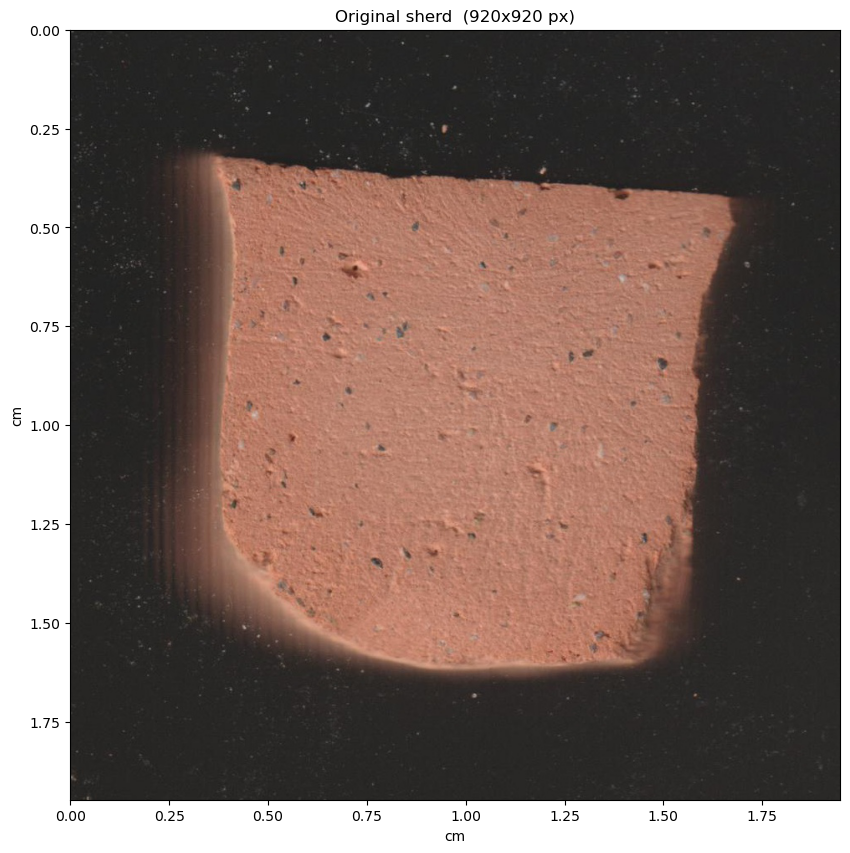

In [5]:
# Load and display the single image
img = cv2.imread(SINGLE_IMAGE)
assert img is not None, f"Could not load image: {SINGLE_IMAGE}"

plt.figure(figsize=(12, 10))
imshow_cm(plt.gca(), img[:, :, ::-1])
plt.title(f"Original sherd  ({img.shape[1]}x{img.shape[0]} px)")
plt.show()

---
## Detection (`core/detection`)

Auto-crop bounds: rows 0:920, cols 0:920  (920 x 920 px  vs original 920 x 920)


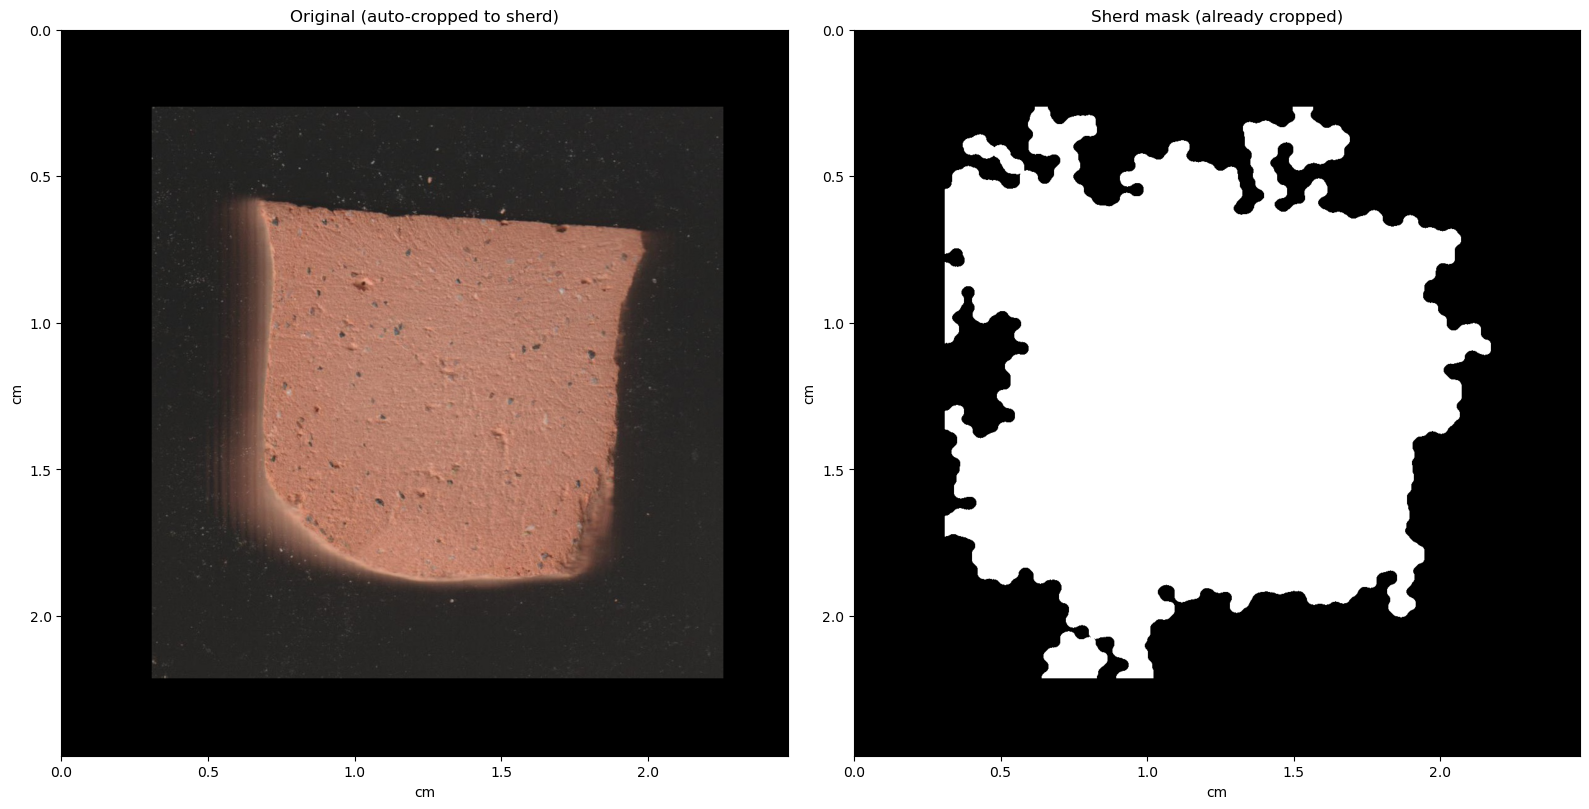

In [6]:
# sherd_mask -- create a binary mask that isolates the sherd from the background
# Returns (mask, crop, sherd_contour) where crop=(y1, y2, x1, x2, pad_top, pad_bottom, pad_left, pad_right)
# in original image coordinates. Extra padding values are >0 when the sherd is near the scan edge.
# The mask is already cropped to the sherd bounding box + 75 px buffer.
# Pass auto_crop=False to get a full-size mask matching the original scan dimensions.
mask, crop, sherd_contour = AMFOrA_public.sherd_mask(img, scan_dpi=SCAN_DPI)
y1, y2, x1, x2 = crop[:4]
print(f"Auto-crop bounds: rows {y1}:{y2}, cols {x1}:{x2}  "
      f"({y2-y1} x {x2-x1} px  vs original {img.shape[0]} x {img.shape[1]})")

# For display, pad the cropped original to match the (possibly padded) mask dimensions
import numpy as np
_img_crop = img[y1:y2, x1:x2]
if len(crop) == 8:
    _pt, _pb, _pl, _pr = crop[4:]
    if _pt or _pb or _pl or _pr:
        _img_crop = np.pad(_img_crop, ((_pt, _pb), (_pl, _pr), (0, 0)),
                           mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
imshow_cm(axes[0], _img_crop[:, :, ::-1])
axes[0].set_title("Original (auto-cropped to sherd)")
imshow_cm(axes[1], mask, cmap="gray")
axes[1].set_title("Sherd mask (already cropped)")
plt.tight_layout()
plt.show()

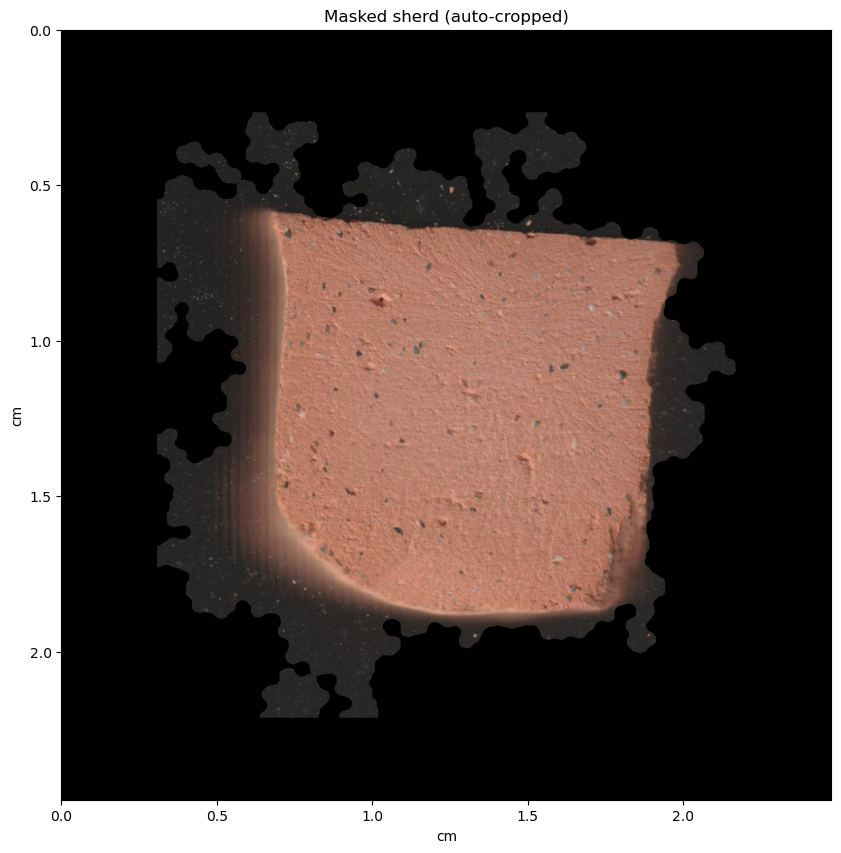

In [7]:
# apply_mask -- crop the original image to the sherd region and apply the mask.
# After this call masked_img is already at the cropped size; no further slicing needed.
masked_img = AMFOrA_public.apply_mask(img, mask, crop)

plt.figure(figsize=(12, 10))
imshow_cm(plt.gca(), masked_img[:, :, ::-1])
plt.title("Masked sherd (auto-cropped)")
plt.show()


Inclusions detected: 7
Voids detected:      0


Text(0.5, 1.0, 'Inclusions (green): 7  |  Voids (red): 0')

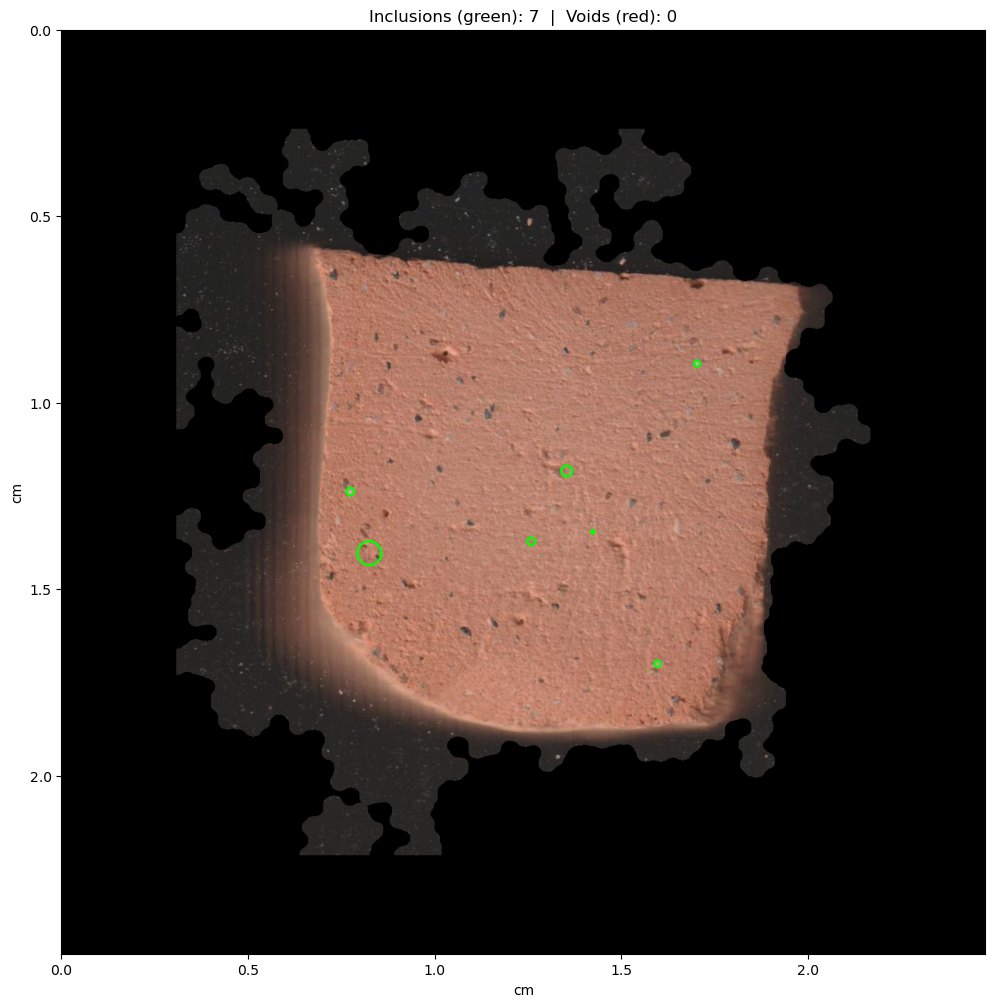

In [8]:
# sherd_blobs -- detect inclusions (light blobs) and voids (dark blobs)
inclusion_blobs, void_blobs = AMFOrA_public.sherd_blobs(masked_img, scan_dpi=SCAN_DPI)
print(f"Inclusions detected: {len(inclusion_blobs)}")
print(f"Voids detected:      {len(void_blobs)}")

# Overlay blob circles on the masked image
overlay = masked_img.copy()
for kp in inclusion_blobs:
    x, y = map(int, kp.pt)
    r = max(1, int(kp.size / 2))
    cv2.circle(overlay, (x, y), r, (0, 255, 0), 2)
for kp in void_blobs:
    x, y = map(int, kp.pt)
    r = max(1, int(kp.size / 2))
    cv2.circle(overlay, (x, y), r, (0, 0, 255), 2)

plt.figure(figsize=(14, 12))
imshow_cm(plt.gca(), overlay[:, :, ::-1])
plt.title(f"Inclusions (green): {len(inclusion_blobs)}  |  Voids (red): {len(void_blobs)}")